# Projeto 01 - Análise Comercial

# 📊 Análise de Vendas e Rentabilidade

## Objetivo

Este projeto tem como objetivo analisar o desempenho comercial da empresa
a partir dos dados de vendas, buscando identificar padrões de faturamento,
lucratividade e desempenho de vendedores e produtos.

A análise será realizada utilizando Python, Pandas e Matplotlib.

### Principais perguntas

- Qual foi o faturamento total?
- Qual foi o lucro total?
- Qual vendedor apresentou o melhor desempenho?
- Quais produtos geraram maior faturamento e lucro?
- Quais produtos apresentam maior margem de lucro?
- Existe relação entre volume de vendas e lucratividade?
- Quais oportunidades de negócio podem ser identificadas?

# 1. Bibliotecas

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# 2. Carga dos dados
Os dados utilizados neste projeto estão armazenados em um arquivo CSV.

A primeira etapa consiste em carregar o conjunto de dados utilizando o Pandas.

In [2]:
DATA_PATH = Path("dados.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["data"])
df.head()

,id_venda,data,vendedor,cidade,cliente,produto,categoria,quantidade,preco_unitario,custo_unitario
0,1,2025-01-05,Ana,São Paulo,Carlos,Notebook,Informática,2,3500,2500
1,2,2025-01-08,Carlos,Rio de Janeiro,Mariana,Mouse,Periféricos,5,80,40
2,3,2025-01-10,Ana,São Paulo,José,Monitor,Informática,1,1200,800
3,4,2025-01-12,Maria,Belo Horizonte,Amanda,Teclado,Periféricos,3,250,120
4,5,2025-01-15,Carlos,Rio de Janeiro,Carlos,Notebook,Informática,1,3500,2500


# 3.  Análise exploratória
Nesta etapa serão avaliadas as principais características do conjunto de dados,
incluindo quantidade de registros, tipos de dados, valores ausentes,
duplicidades e estatísticas descritivas.

In [3]:
df['data'] = pd.to_datetime(df['data'])
df.head()

,id_venda,data,vendedor,cidade,cliente,produto,categoria,quantidade,preco_unitario,custo_unitario
0,1,2025-01-05,Ana,São Paulo,Carlos,Notebook,Informática,2,3500,2500
1,2,2025-01-08,Carlos,Rio de Janeiro,Mariana,Mouse,Periféricos,5,80,40
2,3,2025-01-10,Ana,São Paulo,José,Monitor,Informática,1,1200,800
3,4,2025-01-12,Maria,Belo Horizonte,Amanda,Teclado,Periféricos,3,250,120
4,5,2025-01-15,Carlos,Rio de Janeiro,Carlos,Notebook,Informática,1,3500,2500


## 3.1 Estrutura do conjunto de dados

Primeiramente, serão avaliadas as dimensões do DataFrame e a existência
de registros duplicados.

In [4]:
Info_dataframe = pd.DataFrame({
    'linhas': [df.shape[0]],
    'coluna': [df.shape[1]],
    'duplicadas': [df.duplicated().sum()]
})

Info_dataframe

,linhas,coluna,duplicadas
0,15,10,0


## 3.2 Estrutura e tipos de dados

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_venda        15 non-null     int64         
 1   data            15 non-null     datetime64[ns]
 2   vendedor        15 non-null     object        
 3   cidade          15 non-null     object        
 4   cliente         15 non-null     object        
 5   produto         15 non-null     object        
 6   categoria       15 non-null     object        
 7   quantidade      15 non-null     int64         
 8   preco_unitario  15 non-null     int64         
 9   custo_unitario  15 non-null     int64         
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 1.3+ KB


## 3.3 Estatísticas descritivas

In [6]:
df.describe().round(2)

,id_venda,data,quantidade,preco_unitario,custo_unitario
count,15.00,15,15.00,15.00,15.00
mean,8.00,2025-01-25 03:12:00,2.73,1552.67,1078.67
min,1.00,2025-01-05 00:00:00,1.00,80.00,40.00
25%,4.50,2025-01-13 12:00:00,1.00,250.00,120.00
50%,8.00,2025-01-22 00:00:00,2.00,1200.00,800.00
75%,11.50,2025-02-05 12:00:00,3.50,3500.00,2500.00
max,15.00,2025-02-20 00:00:00,8.00,3500.00,2500.00
std,4.47,NaN,2.15,1489.37,1082.50


## 3.4 Valores ausentes

A análise abaixo verifica a existência de valores ausentes em cada coluna.

In [7]:
df.isna().sum()

id_venda          0
data              0
vendedor          0
cidade            0
cliente           0
produto           0
categoria         0
quantidade        0
preco_unitario    0
custo_unitario    0
dtype: int64

**Resultado:** não foram identificados valores ausentes relevantes no conjunto
de dados.

# 4. Preparação e criação das métricas

A partir dos dados originais serão criadas novas métricas necessárias
para a análise de desempenho comercial e rentabilidade.

In [8]:
df['faturamento'] = (
    df['preco_unitario'] *
    df['quantidade']
)

df['lucro_unitario'] = (
    df['preco_unitario'] -
    df['custo_unitario']
)

df['lucro_total'] = (
    df['lucro_unitario'] *
    df['quantidade']
)

df['margem_lucro'] = (
    df['lucro_unitario'] /
    df['preco_unitario'] *
    100
).round(2)

# 5. Tabela Final

In [9]:
df.head()

,id_venda,data,vendedor,cidade,cliente,produto,categoria,quantidade,preco_unitario,custo_unitario,faturamento,lucro_unitario,lucro_total,margem_lucro
0,1,2025-01-05,Ana,São Paulo,Carlos,Notebook,Informática,2,3500,2500,7000,1000,2000,28.57
1,2,2025-01-08,Carlos,Rio de Janeiro,Mariana,Mouse,Periféricos,5,80,40,400,40,200,50.00
2,3,2025-01-10,Ana,São Paulo,José,Monitor,Informática,1,1200,800,1200,400,400,33.33
3,4,2025-01-12,Maria,Belo Horizonte,Amanda,Teclado,Periféricos,3,250,120,750,130,390,52.00
4,5,2025-01-15,Carlos,Rio de Janeiro,Carlos,Notebook,Informática,1,3500,2500,3500,1000,1000,28.57


# 6. KPIs
Indicadores chave de desempenho (KPIs)

Nesta etapa serão calculados os principais indicadores utilizados
para avaliar o desempenho comercial da empresa.

In [10]:
faturamento_total = df['faturamento'].sum()

faturamento_por_vendedor = (
    df.groupby('vendedor')['faturamento']
    .sum()
)

vendedor_maior_faturamento = (
    faturamento_por_vendedor.idxmax()
)

produto_maior_faturamento = (
    df.groupby('produto')['faturamento']
    .sum()
    .idxmax()
)

cidade_maior_faturamento = (
    df.groupby('cidade')['faturamento']
    .sum()
    .idxmax()
)

lucro_total = df['lucro_total'].sum()

vendedor_maior_lucro = (
    df.groupby('vendedor')['lucro_total']
    .sum()
    .idxmax()
)


relatorio_produto = (
    df.groupby('produto')
    .agg(
        faturamento=('faturamento', 'sum'),
        lucro=('lucro_total', 'sum')
    )
)

relatorio_produto['margem_lucro'] = (
    relatorio_produto['lucro'] /
    relatorio_produto['faturamento'] *
    100
).round(2)

produto_maior_margem = (
    relatorio_produto['margem_lucro']
    .idxmax()
)

margem_total = (
    lucro_total /
    faturamento_total *
    100
).round(2)

ticket_medio = (
    faturamento_total /
    df['id_venda'].nunique()
)

maior_margem = relatorio_produto["margem_lucro"].max()


# 7. Dataframe KPIs

In [11]:

df_kpis = pd.DataFrame({
    'faturamento_total': [faturamento_total],
    'lucro_total': [lucro_total],
    'margem_total': [margem_total],
    'ticket_medio': [ticket_medio],
    'vendedor_maior_faturamento': [vendedor_maior_faturamento],
    'produto_maior_faturamento': [produto_maior_faturamento],
    'cidade_maior_faturamento': [cidade_maior_faturamento],
    'vendedor_maior_lucro': [vendedor_maior_lucro],
    'produto_maior_margem': [produto_maior_margem],
    'maior_margem': [maior_margem],
})

df_kpis

,faturamento_total,lucro_total,margem_total,ticket_medio,vendedor_maior_faturamento,produto_maior_faturamento,cidade_maior_faturamento,vendedor_maior_lucro,produto_maior_margem,maior_margem
0,33170,10730,32.35,2211.333333,Ana,Notebook,São Paulo,Ana,Teclado,52.0


# 8. Gráficos

## Desempenho dos vendedores

Nesta seção, analisaremos o desempenho gerado por cada vendedor,
buscando identificar os profissionais que apresentaram os melhores
resultados no período analisado.

### Faturamento por vendedor

**Pergunta de negócio:** Qual vendedor apresentou o maior faturamento?

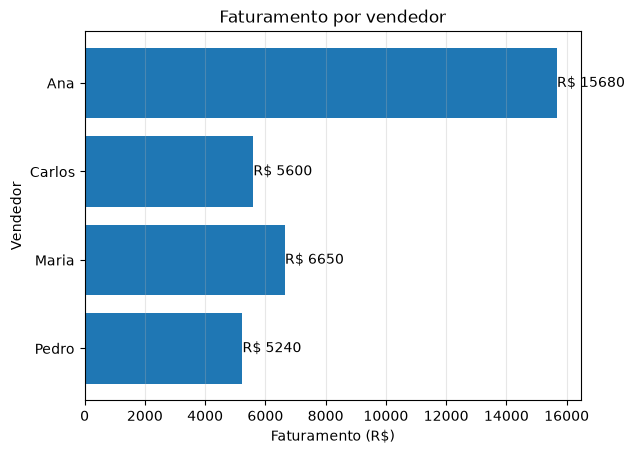

In [19]:
barras = plt.barh(
    faturamento_por_vendedor.index,
    faturamento_por_vendedor.values
)

plt.bar_label(
    barras,
    fmt='R$ %.0f'
)

plt.title('Faturamento por vendedor')
plt.xlabel('Faturamento (R$)')
plt.ylabel('Vendedor')

plt.gca().invert_yaxis()

plt.grid(
    axis='x',
    alpha=0.3
)

plt.show()

#### Insight

Ana apresentou o maior faturamento entre os vendedores analisados,
destacando-se como a profissional com o melhor desempenho em receita
no período.

### Lucro por vendedor

**Pergunta de negócio:** Qual vendedor apresentou o maior lucro?

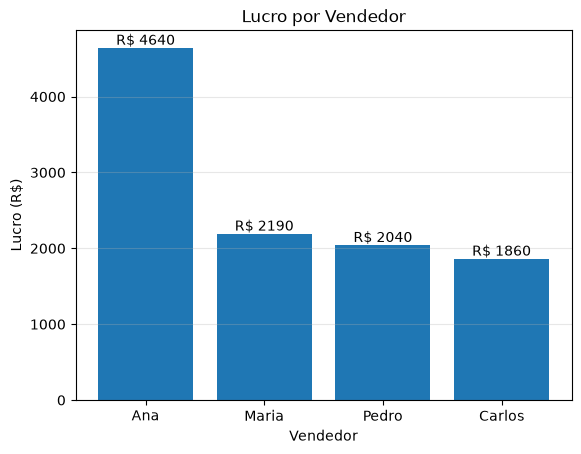

In [13]:
lucro_por_vendedor = (
    df.groupby('vendedor')['lucro_total']
    .sum()
    .sort_values(ascending=False)
)

barras = plt.bar(
    lucro_por_vendedor.index,
    lucro_por_vendedor.values
)

plt.bar_label(
    barras,
    fmt='R$ %.0f'
)

plt.title('Lucro por Vendedor')
plt.xlabel('Vendedor')
plt.ylabel('Lucro (R$)')

plt.grid(
    axis='y',
    alpha=0.3
)

plt.show()

#### Insight

Assim como Ana apresentou o maior faturamento, ela também apresentou o maior lucro entre os vendedores analisados,
destacando-se como a profissional com o melhor desempenho em receita
no período.

### Margem de lucro por vendedor

**Pergunta de negócio:** Qual vendedor apresentou a maior margem de lucro?

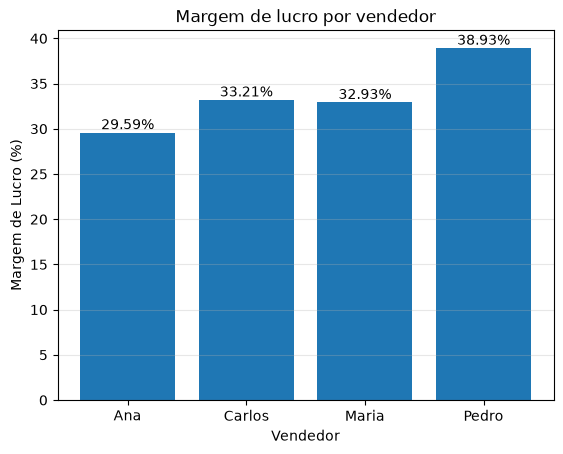

In [14]:
relatorio_vendedor = (
    df.groupby('vendedor')
    .agg(
        faturamento = ('faturamento', 'sum'),
        lucro = ('lucro_total', 'sum')
    )
)

relatorio_vendedor['margem_lucro'] = (
    relatorio_vendedor['lucro'] / 
    relatorio_vendedor['faturamento'] *
    100
).round(2)

barras = (
    relatorio_vendedor.index,
    relatorio_vendedor['margem_lucro']
)

barras = plt.bar(
    relatorio_vendedor.index,
    relatorio_vendedor['margem_lucro']
)

plt.bar_label(
    barras,
    fmt='%.2f%%'
)

plt.title('Margem de lucro por vendedor')
plt.xlabel('Vendedor')
plt.ylabel('Margem de Lucro (%)')

plt.grid(
    axis='y',
    alpha=0.3
)

plt.show()

#### Insight

Apesar de Ana aprensetar o maior faturamento e lucro, Pedro apresentou o maior Margem de lucro entre os vendedores analisados,
destacando-se como a profissional mais eficiente entre o grupo analisado no período.

### Faturamento x Lucro por vendedor

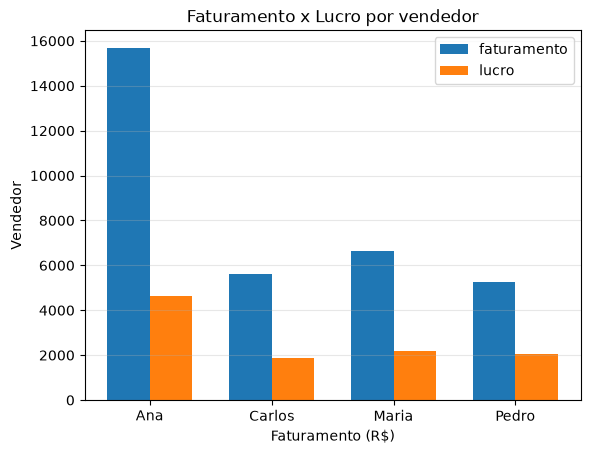

In [15]:
relatorio_vendedor = (
    df.groupby('vendedor')
    .agg(
        faturamento = ('faturamento', 'sum'),
        lucro = ('lucro_total', 'sum')
    )
)

x = np.arange(len(relatorio_vendedor))

largura = 0.35

plt.bar(
    x - largura / 2,
    relatorio_vendedor['faturamento'],
    width=largura,
    label='faturamento'
)

plt.bar(
    x + largura / 2,
    relatorio_vendedor['lucro'],
    width=largura,
    label='lucro'
)

plt.xticks(
    x,
    relatorio_vendedor.index
)

plt.legend()

plt.title('Faturamento x Lucro por vendedor')
plt.ylabel('Vendedor')
plt.xlabel('Faturamento (R$)')

plt.grid(
    axis='y',
    alpha=0.3
)

plt.show()

## Desempenho por produtos

Assim como Ana apresentou o maior faturamento, 
ela também apresentou o maior lucro entre os vendedores analisados,
destacando-se como a profissional com o melhor desempenho financeiro no período.

### Faturamento por produto

**Pergunta de negócio:** Qual produto apresentou o maior faturamento?

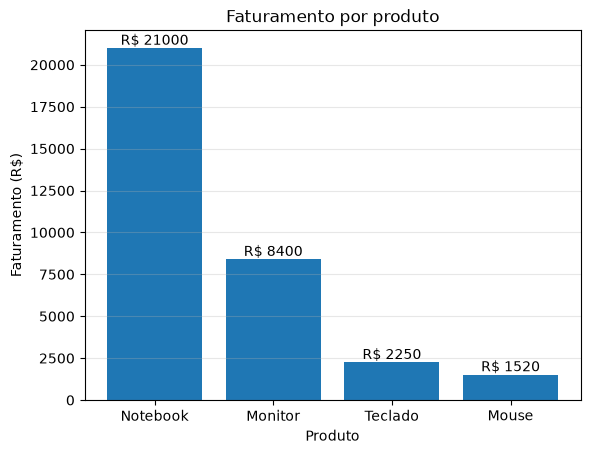

In [16]:
faturamento_por_produto = (
    df.groupby('produto')['faturamento']
    .sum()
    .sort_values(ascending=False)
)

barras = plt.bar(
    faturamento_por_produto.index,
    faturamento_por_produto.values
)

plt.bar_label(
    barras,
    fmt='R$ %.0f'
)

plt.title('Faturamento por produto')
plt.xlabel('Produto')
plt.ylabel('Faturamento (R$)')

plt.grid(
    axis='y',
    alpha=0.3
)

plt.show()

#### Insight

Notebook foi o produto com o maior faturamento dentre os produtos analisados no período.

### Margem de lucro x Faturamento

**Pergunta de negócio**:

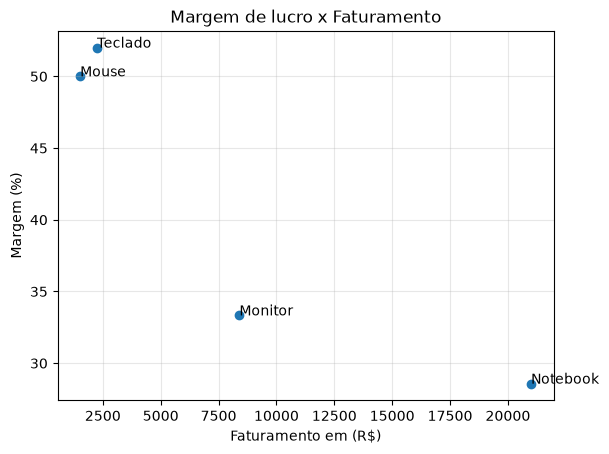

In [17]:
relatorio_produto = (
    df.groupby('produto')
    .agg(
        faturamento=('faturamento', 'sum'),
        lucro=('lucro_total', 'sum')
    )
)

relatorio_produto['margem_lucro'] = (
    relatorio_produto['lucro'] /
    relatorio_produto['faturamento'] *
    100
).round(2)

plt.scatter(
    relatorio_produto['faturamento'],
    relatorio_produto['margem_lucro']
)

for produto, dados in relatorio_produto.iterrows():
    plt.annotate(
        produto,
        (dados['faturamento'], dados['margem_lucro'])
    )



plt.title('Margem de lucro x Faturamento')
plt.ylabel('Margem (%)')
plt.xlabel('Faturamento em (R$)')

plt.grid(alpha=0.3)

plt.show()

### Quantidade vendida × Lucro total

**Pergunta de negócio**

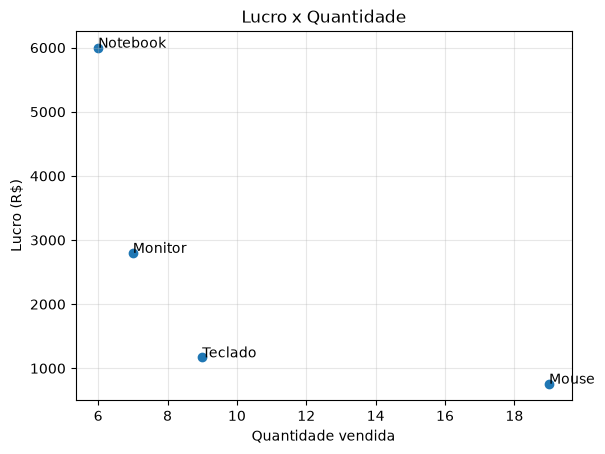

In [18]:
relatorio_produto = (
    df.groupby('produto')
    .agg(
        quantidade=('quantidade', 'sum'),
        lucro=('lucro_total', 'sum')
    )
)

plt.scatter(
    relatorio_produto['quantidade'],
    relatorio_produto['lucro']
)

for produto, dados in relatorio_produto.iterrows():
    plt.annotate(
        produto,
        (dados['quantidade'], dados['lucro'])
    )

plt.title('Lucro x Quantidade')
plt.ylabel('Lucro (R$)')
plt.xlabel('Quantidade vendida')

plt.grid(alpha=0.3)

plt.show()

# Insights de negócio

Apesar de Ana apresentar o maior faturamento e lucro absoluto, Pedro apresentou uma margem de lucro superior, indicando maior eficiência na geração de lucro sobre suas vendas.
O Notebook apresentou o maior faturamento entre os produtos analisados. Entretanto, Mouse e Teclado apresentaram margens de lucro superiores, com o Teclado apresentando a maior margem.
O Mouse apresentou o maior volume de unidades vendidas, porém apresentou a menor lucratividade. Isso indica que seu alto volume de vendas não necessariamente se traduz em maior geração de lucro.
O Notebook apresentou um volume de vendas inferior ao Mouse, mas conseguiu gerar maior lucro, indicando uma relação mais favorável entre volume de vendas e rentabilidade.
O Notebook apresenta um volume de vendas inferior ao Mouse, mas gera maior lucro.

# Recomendações de negócio

**1. Avaliar a rentabilidade do Mouse**

Apesar de apresentar o maior volume de unidades vendidas, o Mouse gera uma lucratividade menor em comparação aos demais produtos. Recomenda-se avaliar sua estrutura de custos e sua estratégia de precificação para identificar oportunidades de aumentar sua rentabilidade.

**2. Explorar o potencial do Teclado**

O Teclado apresentou a maior margem de lucro entre os produtos analisados. Recomenda-se avaliar ações comerciais e promocionais para aumentar seu volume de vendas, desde que seja possível manter a margem de lucro atual.

**3. Utilizar as boas práticas da Ana como referência**

Ana apresentou o maior faturamento e lucro entre os vendedores analisados. Recomenda-se investigar quais estratégias, práticas comerciais ou características contribuem para seu desempenho e avaliar se essas práticas podem ser compartilhadas com os demais vendedores, especialmente na comercialização dos produtos com maior retorno financeiro.


## Conclusão

A análise demonstrou que maior volume de vendas não implica necessariamente maior rentabilidade. Enquanto o Mouse apresentou o maior volume de unidades vendidas, o Notebook apresentou maior faturamento e lucro, e o Teclado apresentou a maior margem. Entre os vendedores, Ana apresentou os melhores resultados absolutos de faturamento e lucro.